# Cryptocurrency Volatility Prediction Using ML Models

We compare 6 models: HAR-X (OLS, Ridge, Lasso, Gamma regression), XGBoost, LightGBM

Target variable: daily realized volatility of Bitcoin (RV_BTC)


## 1. loading libraries

In [ ]:
!pip install xgboost lightgbm scikit-learn -q

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pylab as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, GammaRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

import xgboost as xgb
import lightgbm as lgb

random_seed = 42
np.random.seed(random_seed)

## 2. data

In [ ]:
# loading dataset
df = pd.read_csv('btc_dataset_new.csv', index_col=0, parse_dates=True)
df.shape

(1994, 18)

In [ ]:
# five first observations
df.head()

,RV_BTC,btc_close,btc_volume,btc_trade_count,hash_rate,difficulty,avg_conf_time,tx_per_block,avg_block_size,fear_greed,sp500_close,sp500_volume,vix_close,RV_lag1,RV_lag2,RV_lag3,RV_ma7,RV_ma30
date,,,,,,,,,,,,,,,,,,
2019-07-17,5.827713,9439.59,97219.443413,796646.0,7.299426e+07,9.064160e+12,13.713174,2242.820988,1.098875,34.0,3004.040039,3.297030e+09,12.86,7.430676,5.516580,4.679082,5.730280,5.645698
2019-07-18,10.519966,9667.92,84942.672717,757742.0,5.992738e+07,9.064160e+12,43.403932,2442.796992,1.153725,19.0,2984.419922,3.185650e+09,13.97,7.461420,7.430676,5.516580,5.992263,5.723315
2019-07-19,4.558965,10627.16,80283.310252,734821.0,5.452040e+07,9.064160e+12,55.572236,2609.462810,1.261034,40.0,2995.110107,3.369820e+09,13.53,5.827713,7.461420,7.430676,5.968673,5.790680
2019-07-20,3.252035,10504.29,56546.932133,567735.0,5.316866e+07,9.064160e+12,120.624187,2541.449153,1.262904,42.0,2976.610107,3.285890e+09,14.45,10.519966,5.827713,7.461420,6.525108,6.046798
2019-07-21,3.350670,10740.23,47331.899848,461660.0,7.975298e+07,9.064160e+12,179.729274,1824.870056,1.047571,34.0,2976.610107,3.285890e+09,14.45,4.558965,10.519966,5.827713,6.570629,6.134926


In [ ]:
# descriptive statistics
df.describe()

,RV_BTC,btc_close,btc_volume,btc_trade_count,hash_rate,difficulty,avg_conf_time,tx_per_block,avg_block_size,fear_greed,sp500_close,sp500_volume,vix_close,RV_lag1,RV_lag2,RV_lag3,RV_ma7,RV_ma30
count,1994.000000,1994.000000,1994.000000,1.994000e+03,1.994000e+03,1.994000e+03,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1.994000e+03,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,2.840418,33943.687081,81020.373250,2.105540e+06,2.814563e+08,3.874629e+13,225.247030,2417.162181,1.361728,48.916750,4154.063065,4.330942e+09,20.725828,2.844364,2.846614,2.848637,2.849971,2.867938
std,1.931867,21548.211582,88582.814919,2.193333e+06,1.982707e+08,2.689037e+13,1005.195949,854.625284,0.298307,22.284708,809.613315,1.175137e+09,8.019455,1.937604,1.938164,1.938016,1.403793,1.116101
min,0.309409,4800.000000,7308.955420,1.913240e+05,5.316866e+07,9.013787e+12,5.666155,1023.291209,0.643639,5.000000,2237.399902,0.000000e+00,11.540000,0.309409,0.309409,0.309409,0.715396,1.041176
25%,1.640739,16474.462500,32801.328648,7.842708e+05,1.262898e+08,1.756770e+13,20.800096,1845.689057,1.150485,28.000000,3585.267456,3.647768e+09,15.047500,1.639454,1.640739,1.644973,1.965103,2.139383
50%,2.466973,29461.925000,50820.611750,1.327264e+06,1.988993e+08,2.796715e+13,51.913907,2144.012820,1.304043,49.000000,4145.385010,4.020690e+09,18.840000,2.467911,2.468726,2.469853,2.570692,2.658405
75%,3.448525,48298.177500,84830.444439,2.321202e+06,3.981535e+08,5.391117e+13,117.686801,2725.221062,1.615954,70.000000,4551.405151,4.687198e+09,24.210000,3.448875,3.451407,3.453286,3.330441,3.354350
max,28.553471,106133.740000,760705.362783,1.522359e+07,8.898460e+08,1.097821e+14,25809.729056,5517.916667,2.524785,95.000000,6090.270020,9.976520e+09,82.690002,28.553471,28.553471,28.553471,15.294218,7.322923


In [ ]:
# checking for missing values
df.isnull().sum()

,0
RV_BTC,0
btc_close,0
btc_volume,0
btc_trade_count,0
hash_rate,0
difficulty,0
avg_conf_time,0
tx_per_block,0
avg_block_size,0
fear_greed,0


## 3. exploratory data analysis

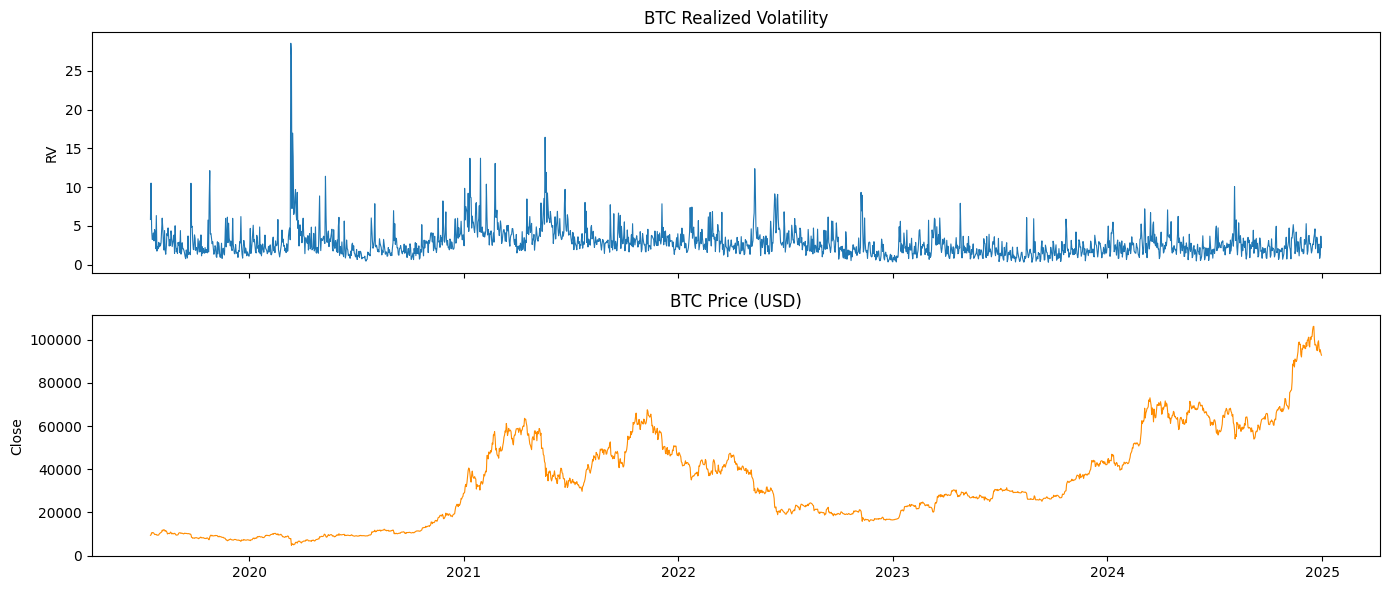

In [ ]:
# visualisation of time series
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df.index, df['RV_BTC'], linewidth=0.8)
axes[0].set_title('BTC Realized Volatility')
axes[0].set_ylabel('RV')
axes[1].plot(df.index, df['btc_close'], color='darkorange', linewidth=0.8)
axes[1].set_title('BTC Price (USD)')
axes[1].set_ylabel('Close')
plt.tight_layout()

Distribution of RV_BTC: right-skewed distribution is typical for volatility series

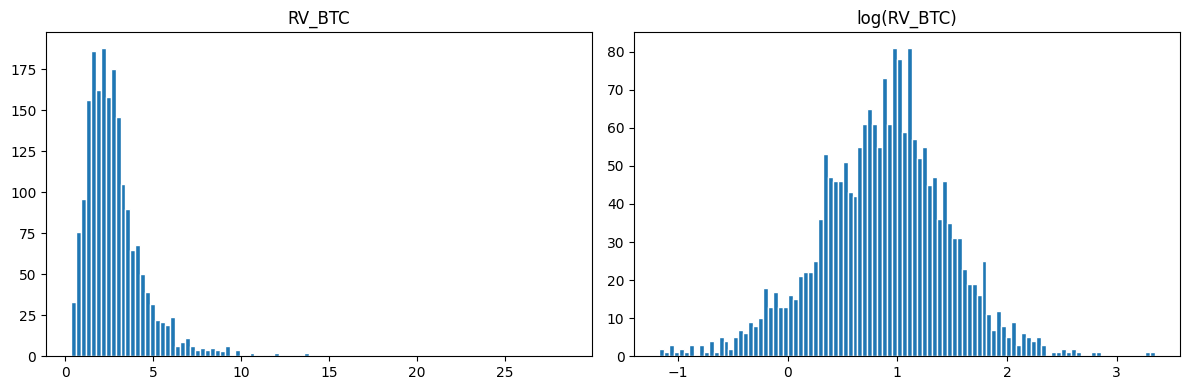

In [ ]:
# visualisation of distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['RV_BTC'], bins=100, edgecolor='white')
axes[0].set_title('RV_BTC')
axes[1].hist(np.log(df['RV_BTC']), bins=100, edgecolor='white')
axes[1].set_title('log(RV_BTC)')
plt.tight_layout()

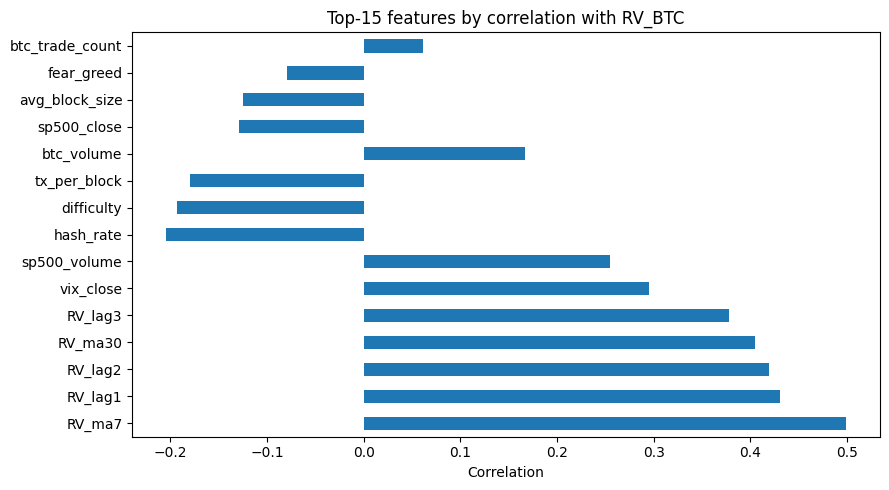

In [ ]:
# correlation of features with the target variable
corr = df.corr()['RV_BTC'].drop('RV_BTC').sort_values(key=abs, ascending=False)
corr.head(15).plot(kind='barh', figsize=(9, 5))
plt.title('Top-15 features by correlation with RV_BTC')
plt.xlabel('Correlation')
plt.tight_layout()

## 4. model evaluation metrics

We use three metrics standard in the volatility forecasting literature (Patton, 2011): RMSE, MAE, and QLIKE.
Scaled versions (RMSSE, MASE, QLIKES) benchmark each model against a naive random walk forecast.

In [ ]:
# calculation of metrics
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def qlike(y_true, y_pred):
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def evaluate(y_true, y_pred, name=''):
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_naive = y_true[:-1]
    yt, yp  = y_true[1:], y_pred[1:]
    return {
        'Model':  name,
        'RMSE':   rmse(yt, yp),
        'RMSSE':  rmse(yt, yp) / rmse(yt, y_naive),
        'MAE':    mae(yt, yp),
        'MASE':   mae(yt, yp)  / mae(yt, y_naive),
        'QLIKE':  qlike(yt, yp),
        'QLIKES': qlike(yt, yp) / qlike(yt, y_naive),
    }

## 5. setup

In [ ]:
# model setup
target   = 'RV_BTC'
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

tscv = TimeSeriesSplit(n_splits=4)

## 6. models

We estimate 6 models. Linear models HAR-X (OLS, Ridge, Lasso, Gamma) require feature scaling. MinMaxScaler is fitted on the training set only to ensure consistent scaling between train and test.
Tree-based models (XGBoost, LightGBM) are scale-invariant and require no scaling.


### 6.1 linear models

**OLS**: standard linear regression, no regularization;

**Ridge**: OLS with L2 penalty: shrinks all coefficients toward zero but does not eliminate any;

**Lasso**: OLS with L1 penalty: sets coefficients of irrelevant features to exactly zero, performing automatic feature selection;

**Gamma regression**: GLM with log link and gamma distribution assumption.


In [ ]:
# write function for linear model training
def fit_linear_models(X_train, y_train, X_test, y_test, tscv):
    results = []

    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # OLS
    ols = LinearRegression()
    ols.fit(X_train_sc, y_train)
    ols_pred = ols.predict(X_test_sc)
    results.append(evaluate(y_test, ols_pred, 'OLS'))

    # Ridge
    gs_ridge = GridSearchCV(
        Ridge(),
        {'alpha': [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1.0]},
        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1,
    )
    gs_ridge.fit(X_train_sc, y_train)
    ridge_pred = gs_ridge.best_estimator_.predict(X_test_sc)
    results.append(evaluate(y_test, ridge_pred, 'Ridge'))

    # Lasso
    gs_lasso = GridSearchCV(
        Lasso(max_iter=10_000),
        {'alpha': [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]},
        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1,
    )
    gs_lasso.fit(X_train_sc, y_train)
    lasso_pred = gs_lasso.best_estimator_.predict(X_test_sc)
    results.append(evaluate(y_test, lasso_pred, 'Lasso'))

    # Gamma regression
    gs_gamma = GridSearchCV(
        GammaRegressor(max_iter=10_000, tol=1e-7),
        {'alpha': [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1.0]},
        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1,
    )
    gs_gamma.fit(X_train_sc, y_train)
    gamma_pred = gs_gamma.best_estimator_.predict(X_test_sc)
    results.append(evaluate(y_test, gamma_pred, 'Gamma'))

    return pd.DataFrame(results).set_index('Model').round(4), ols, gs_ridge.best_estimator_, gs_lasso.best_estimator_, gs_gamma.best_estimator_, ols_pred, ridge_pred, lasso_pred, gamma_pred, scaler

### 6.2 decision trees

**XGBoost**: level-wise tree growth; we use gamma objective to handle the strictly positive target variable;

**LightGBM**: leaf-wise tree growth; same hyperparameters and search grid for a fair comparison.


In [ ]:
# write function for decision trees training
def fit_tree_models(X_train, y_train, X_test, y_test, tscv):
    results = []

    param_grid = {
        'n_estimators':  [64, 128, 256],
        'learning_rate': [0.01, 0.03, 0.05],
        'max_depth':     [2, 3, 4],
    }

    # XGBoost
    gs_xgb = GridSearchCV(
        xgb.XGBRegressor(
            objective='reg:gamma', reg_lambda=0.5, reg_alpha=0.5,
            colsample_bytree=0.8, random_state=random_seed, verbosity=0,
        ),
        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1,
    )
    gs_xgb.fit(X_train, y_train)
    xgb_pred = gs_xgb.best_estimator_.predict(X_test)
    results.append(evaluate(y_test, xgb_pred, 'XGBoost'))

    # LightGBM
    gs_lgb = GridSearchCV(
        lgb.LGBMRegressor(
            objective='gamma', reg_lambda=0.5, reg_alpha=0.5,
            colsample_bytree=0.8, random_state=random_seed, verbosity=-1,
        ),
        param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1,
    )
    gs_lgb.fit(X_train, y_train)
    lgb_pred = gs_lgb.best_estimator_.predict(X_test)
    results.append(evaluate(y_test, lgb_pred, 'LightGBM'))

    return pd.DataFrame(results).set_index('Model').round(4), gs_xgb.best_estimator_, gs_lgb.best_estimator_, xgb_pred, lgb_pred

## 7. results

### 7.1 main split (80/20)

In [ ]:
# split dataset: train 80%, test 20%
split_idx = int(np.ceil(len(df) * 0.8))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), X_train.index[0].date(), '—', X_train.index[-1].date())
print('Test: ', len(X_test),  X_test.index[0].date(),  '—', X_test.index[-1].date())

Train: 1596 2019-07-17 — 2023-11-28
Test:  398 2023-11-29 — 2024-12-31


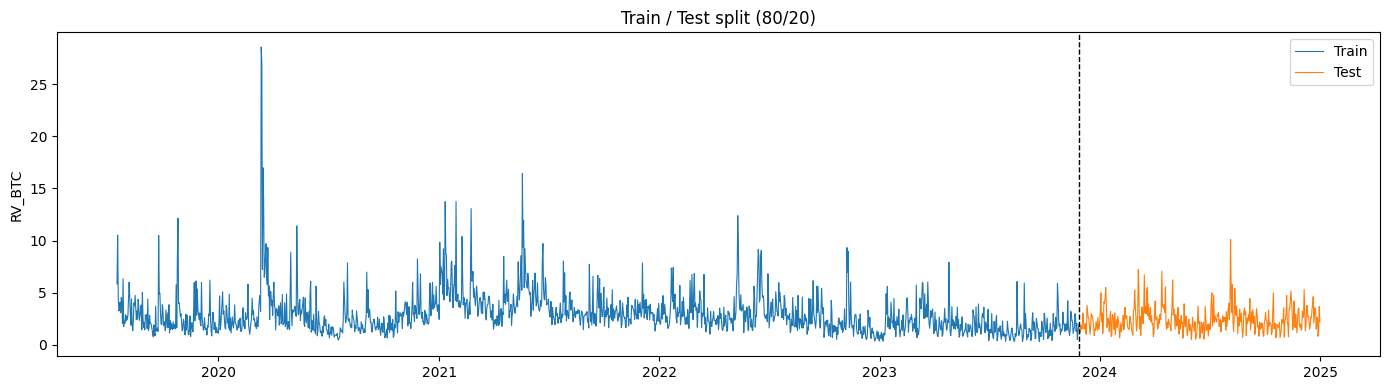

In [ ]:
# visualisation of the 1st split
plt.figure(figsize=(14, 4))
plt.plot(y_train.index, y_train, label='Train', linewidth=0.8)
plt.plot(y_test.index,  y_test,  label='Test',  linewidth=0.8)
plt.axvline(x=y_train.index[-1], color='black', linestyle='--', linewidth=1)
plt.title('Train / Test split (80/20)')
plt.ylabel('RV_BTC')
plt.legend()
plt.tight_layout()

In [ ]:
# look at the results of linear models
res_linear, ols_m, ridge_m, lasso_m, gamma_m, ols_pred, ridge_pred, lasso_pred, gamma_pred, scaler_main = fit_linear_models(X_train, y_train, X_test, y_test, tscv)
res_linear

/tmp/ipykernel_894/2672448386.py:10: RuntimeWarning: invalid value encountered in log
  return np.mean(ratio - np.log(ratio) - 1)


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5510,1.1618,1.1343,1.1139,NaN,NaN
Ridge,1.4107,1.0567,1.0236,1.0052,0.2538,1.5856
Lasso,1.1631,0.8712,0.8334,0.8184,0.1081,0.6751
Gamma,1.3349,0.9999,0.9464,0.9294,0.1611,1.0065


In [ ]:
# look at the results of decision trees models
res_trees, xgb_m, lgb_m, xgb_pred, lgb_pred = fit_tree_models(X_train, y_train, X_test, y_test, tscv)
res_trees

,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
XGBoost,1.1403,0.8541,0.8317,0.8168,0.1041,0.6501
LightGBM,1.1434,0.8564,0.8493,0.8341,0.1043,0.6518


In [ ]:
# all results for 80/20 split
results_main = pd.concat([res_linear, res_trees])
results_main

,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5510,1.1618,1.1343,1.1139,NaN,NaN
Ridge,1.4107,1.0567,1.0236,1.0052,0.2538,1.5856
Lasso,1.1631,0.8712,0.8334,0.8184,0.1081,0.6751
Gamma,1.3349,0.9999,0.9464,0.9294,0.1611,1.0065
XGBoost,1.1403,0.8541,0.8317,0.8168,0.1041,0.6501
LightGBM,1.1434,0.8564,0.8493,0.8341,0.1043,0.6518


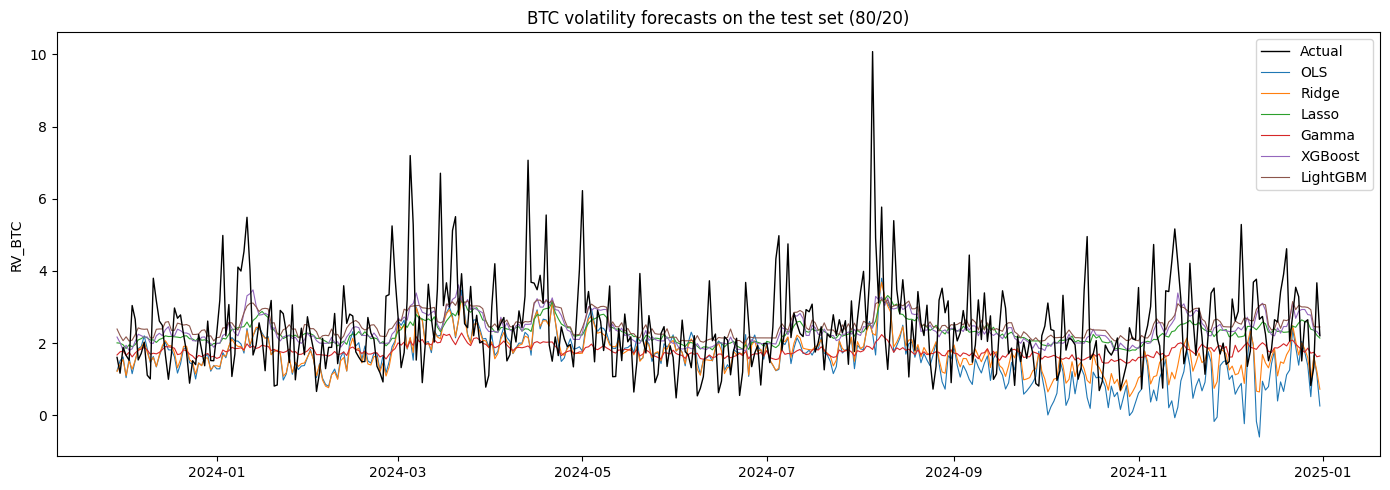

In [ ]:
# visualisation of different models' predictions
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, color='black', label='Actual', linewidth=1.0, zorder=5)
plt.plot(y_test.index, ols_pred,   label='OLS',      linewidth=0.8)
plt.plot(y_test.index, ridge_pred, label='Ridge',    linewidth=0.8)
plt.plot(y_test.index, lasso_pred, label='Lasso',    linewidth=0.8)
plt.plot(y_test.index, gamma_pred, label='Gamma',    linewidth=0.8)
plt.plot(y_test.index, xgb_pred,   label='XGBoost',  linewidth=0.8)
plt.plot(y_test.index, lgb_pred,   label='LightGBM', linewidth=0.8)
plt.title('BTC volatility forecasts on the test set (80/20)')
plt.ylabel('RV_BTC')
plt.legend()
plt.tight_layout()

### 7.2 feature importance

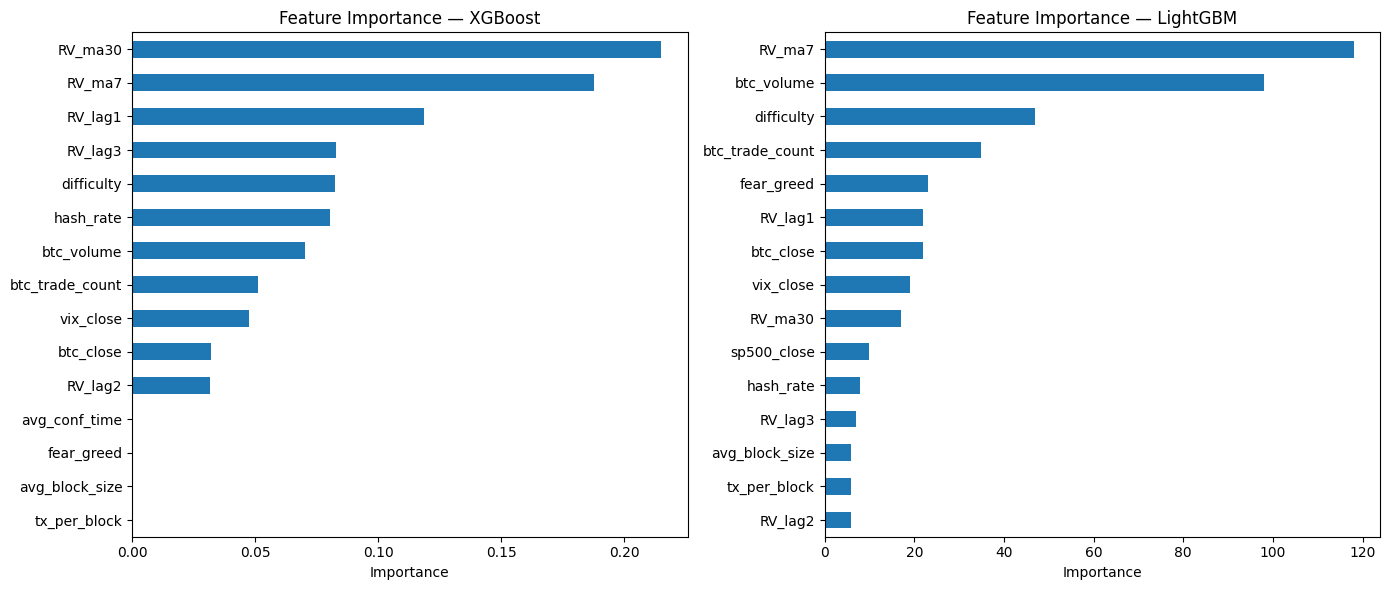

In [ ]:
# figures with feature importance for both busting models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in zip(axes, [xgb_m, lgb_m], ['XGBoost', 'LightGBM']):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.nlargest(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Feature Importance — ' + name)
    ax.set_xlabel('Importance')

plt.tight_layout()

## 8. "robustness checks"

We assess robustness of the main results across two alternative setups:
1. **Post-COVID split**: training data starts from January 2021 to exclude the COVID-19 shock;
2. **70/30 split**: larger test set to verify results hold over a longer out-of-sample period


### 9.1 post-COVID split (train from 2021)

In [ ]:
# 2nd split: post covid; 80 train, 20 test
covid_start = '2021-01-01'

X_train_pc = X[covid_start : X_test.index[0] - pd.Timedelta(days=1)]
y_train_pc = y[covid_start : X_test.index[0] - pd.Timedelta(days=1)]

print('Train (post-COVID):', len(X_train_pc),
      X_train_pc.index[0].date(), '—', X_train_pc.index[-1].date())
print('Test:              ', len(X_test),
      X_test.index[0].date(), '—', X_test.index[-1].date())

Train (post-COVID): 1062 2021-01-01 — 2023-11-28
Test:               398 2023-11-29 — 2024-12-31


In [ ]:
# all results for post-covid split
res_linear_pc, *_ = fit_linear_models(X_train_pc, y_train_pc, X_test, y_test, tscv)
res_trees_pc,  *_ = fit_tree_models(X_train_pc,  y_train_pc, X_test, y_test, tscv)

results_pc = pd.concat([res_linear_pc, res_trees_pc])
results_pc

/tmp/ipykernel_894/2672448386.py:10: RuntimeWarning: invalid value encountered in log
  return np.mean(ratio - np.log(ratio) - 1)


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5912,1.1918,1.1729,1.1518,NaN,NaN
Ridge,1.4548,1.0897,1.0594,1.0404,0.2762,1.7252
Lasso,1.2971,0.9715,0.9193,0.9028,0.1539,0.9615
Gamma,1.4173,1.0616,1.0197,1.0014,0.2017,1.2602
XGBoost,1.2446,0.9322,0.8756,0.8599,0.1348,0.8418
LightGBM,1.1611,0.8697,0.8234,0.8086,0.1082,0.6757


### 8.2 alternative split (70/30)

In [ ]:
# 3rd split: train 70, test 30
split_idx_70 = int(np.ceil(len(df) * 0.7))

X_train_70, X_test_70 = X.iloc[:split_idx_70], X.iloc[split_idx_70:]
y_train_70, y_test_70 = y.iloc[:split_idx_70], y.iloc[split_idx_70:]

print('Train:', len(X_train_70), X_train_70.index[0].date(), '—', X_train_70.index[-1].date())
print('Test: ', len(X_test_70),  X_test_70.index[0].date(),  '—', X_test_70.index[-1].date())

Train: 1396 2019-07-17 — 2023-05-12
Test:  598 2023-05-13 — 2024-12-31


In [ ]:
# all results for 70/30 split
res_linear_70, *_ = fit_linear_models(X_train_70, y_train_70, X_test_70, y_test_70, tscv)
res_trees_70,  *_ = fit_tree_models(X_train_70,  y_train_70, X_test_70, y_test_70, tscv)

results_70 = pd.concat([res_linear_70, res_trees_70])
results_70

/tmp/ipykernel_894/2672448386.py:10: RuntimeWarning: invalid value encountered in log
  return np.mean(ratio - np.log(ratio) - 1)
/tmp/ipykernel_894/2672448386.py:10: RuntimeWarning: invalid value encountered in log
  return np.mean(ratio - np.log(ratio) - 1)


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.9069,1.4714,1.4475,1.5071,NaN,NaN
Ridge,1.7494,1.3498,1.3245,1.3790,NaN,NaN
Lasso,1.2113,0.9346,0.9790,1.0193,0.1508,0.7643
Gamma,1.1692,0.9022,0.8520,0.8871,0.1432,0.7258
XGBoost,1.1501,0.8874,0.8895,0.9262,0.1388,0.7035
LightGBM,1.2280,0.9475,0.9935,1.0345,0.1554,0.7877


## 9. summary

In [ ]:
# all results for all splits
print('Main results (80/20):')
display(results_main)

print('Post-COVID split (train from 2021):')
display(results_pc)

print('Alternative split (70/30):')
display(results_70)

Main results (80/20):


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5510,1.1618,1.1343,1.1139,NaN,NaN
Ridge,1.4107,1.0567,1.0236,1.0052,0.2538,1.5856
Lasso,1.1631,0.8712,0.8334,0.8184,0.1081,0.6751
Gamma,1.3349,0.9999,0.9464,0.9294,0.1611,1.0065
XGBoost,1.1403,0.8541,0.8317,0.8168,0.1041,0.6501
LightGBM,1.1434,0.8564,0.8493,0.8341,0.1043,0.6518


Post-COVID split (train from 2021):


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5912,1.1918,1.1729,1.1518,NaN,NaN
Ridge,1.4548,1.0897,1.0594,1.0404,0.2762,1.7252
Lasso,1.2971,0.9715,0.9193,0.9028,0.1539,0.9615
Gamma,1.4173,1.0616,1.0197,1.0014,0.2017,1.2602
XGBoost,1.2446,0.9322,0.8756,0.8599,0.1348,0.8418
LightGBM,1.1611,0.8697,0.8234,0.8086,0.1082,0.6757


Alternative split (70/30):


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.9069,1.4714,1.4475,1.5071,NaN,NaN
Ridge,1.7494,1.3498,1.3245,1.3790,NaN,NaN
Lasso,1.2113,0.9346,0.9790,1.0193,0.1508,0.7643
Gamma,1.1692,0.9022,0.8520,0.8871,0.1432,0.7258
XGBoost,1.1501,0.8874,0.8895,0.9262,0.1388,0.7035
LightGBM,1.2280,0.9475,0.9935,1.0345,0.1554,0.7877


## 10. save results to csv

In [ ]:
# save results to .csv files
results_main.to_csv('results_main.csv')
results_pc.to_csv('results_postcovid.csv')
results_70.to_csv('results_7030.csv')

Saved: results_main.csv, results_postcovid.csv, results_7030.csv


,RMSE,RMSSE,MAE,MASE,QLIKE,QLIKES
Model,,,,,,
OLS,1.5510,1.1618,1.1343,1.1139,NaN,NaN
Ridge,1.4107,1.0567,1.0236,1.0052,0.2538,1.5856
Lasso,1.1631,0.8712,0.8334,0.8184,0.1081,0.6751
Gamma,1.3349,0.9999,0.9464,0.9294,0.1611,1.0065
XGBoost,1.1403,0.8541,0.8317,0.8168,0.1041,0.6501
LightGBM,1.1434,0.8564,0.8493,0.8341,0.1043,0.6518


- `date` — calendar date of the observation (daily)
- `RV_BTC` — Realized Volatility of Bitcoin for that day
- `btc_close` — BTC closing price (in USDT) for the day
- `btc_volume` — BTC trading volume (in USDT) for the day
- `btc_trade_count` — number of BTC trades executed that day
- `hash_rate` — Bitcoin network hash rate; total computing power securing the network
- `difficulty` — mining difficulty; how hard it is to find a new block
- `avg_conf_time` — average transaction confirmation time on the network (in minutes)
- `tx_per_block` — average number of transactions per block
- `avg_block_size` — average block size (in MB)
- `fear_greed` — Crypto Fear & Greed Index, scaled 0–100
- `sp500_close` — S&P 500 index closing price
- `sp500_volume` — S&P 500 trading volume
- `vix_close` — VIX index value (stock market "fear index")
- `RV_lag1` — RV lagged by 1 day
- `RV_lag2` — RV lagged by 2 days
- `RV_lag3` — RV lagged by 3 days
- `RV_ma7` — 7-day rolling mean of RV
- `RV_ma30` — 30-day rolling mean of RV